# DD CrB O-C Modeling
This notebook demonstrates O-C modeling for DD CrB.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ocpy.data import Data

column_mapping = {
    "BJD Min": "minimum_time",
    "Err": "minimum_time_error",
    "Type": "minimum_type",
    "obs type": "labels"
}

data = Data.from_file("DD_CrB_Minima.xlsx", columns=column_mapping)
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2455611.92657
period = 0.161770446

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="lmfit"
)
print("Data:", data)
print("OC:", oc)

Data:      minimum_time  minimum_time_error       weights minimum_type      labels
0    2.454532e+06            0.000015  4.444444e+09            p  Literature
1    2.454533e+06            0.000015  4.444444e+09            p  Literature
2    2.454536e+06            0.000015  4.444444e+09            p  Literature
3    2.454537e+06            0.000015  4.444444e+09            p  Literature
4    2.454555e+06            0.000015  4.444444e+09            p  Literature
..            ...                 ...           ...          ...         ...
474  2.460740e+06            0.000029  1.167229e+09            p    Ždánice 
475  2.460460e+06            0.000028  1.275510e+09            p    Ždánice 
476  2.460069e+06            0.000014  5.102041e+09            p    Ždánice 
477  2.460057e+06            0.000003  1.111111e+11            p    Ždánice 
478  2.460461e+06            0.000003  1.111111e+11            p    Ždánice 

[479 rows x 5 columns]
OC:      minimum_time  minimum_time_error     

<Axes: ylabel='O−C'>

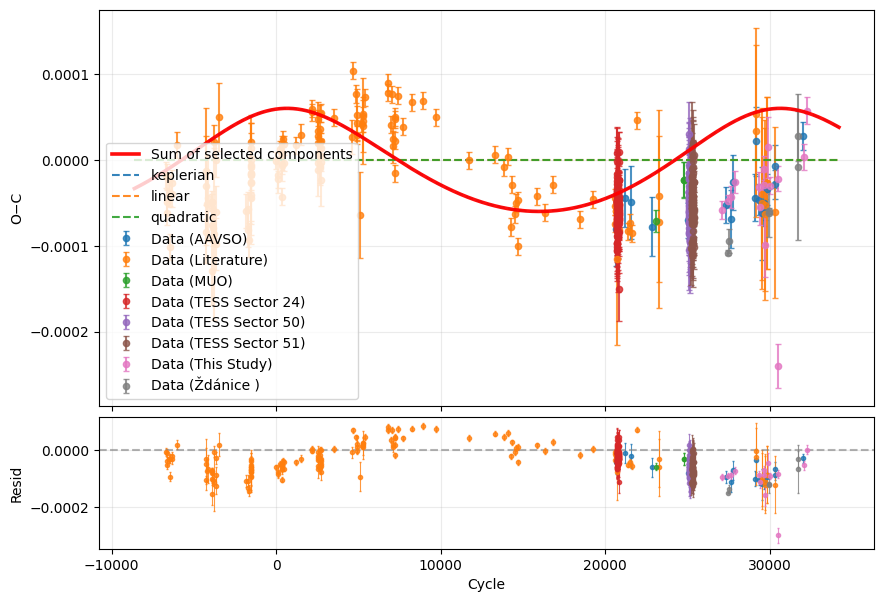

In [3]:
from ocpy.oc import Keplerian, Linear, Quadratic, Parameter

kep = Keplerian(
    amp=Parameter(value=6e-05, std=4e-5, min=0.0, max=1e-4, fixed=False),
    e=Parameter(value=.2, std=.1, min=0.0, max=0.95, fixed=False),
    omega=Parameter(value=8e+01, std=180, min=0.0, max=360.0, fixed=False),
    P=Parameter(value=3e+04, std=10000, min=10000, fixed=False),
    T0=Parameter(value=3e+04, std=30000, fixed=False)
)
lin = Linear(
    a=Parameter(value=0, std=1e-9, min=-1e-9, fixed=False),
    b=Parameter(value=0, std=1e-4, min=-1e-4, fixed=False)
)
quad = Quadratic(
    q=Parameter(value=0, std=1e-9, min=-1e-9, fixed=False)
)
models = [kep, lin, quad]
oc.plot(models)

In [4]:
res = oc.fit(models, method="nelder")

<Axes: ylabel='O−C'>

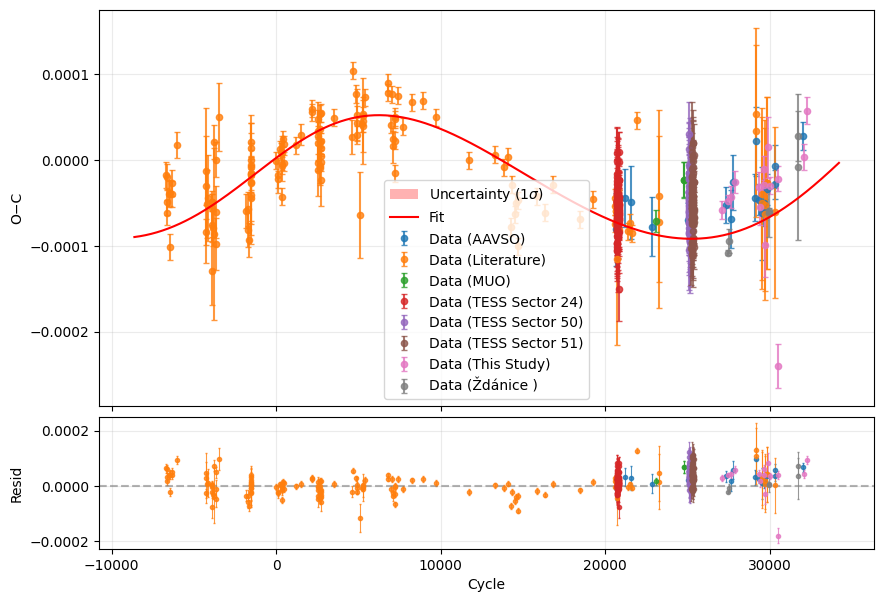

In [5]:
oc.plot(res)